In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
df=pd.read_csv(r"C:\Users\User\Desktop\jupyter notebook\dynamic_pricing_engine1.0\online_retail_II.csv",encoding="cp1252")

In [4]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


In [5]:
df=df.drop_duplicates()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135037
Country             0
dtype: int64

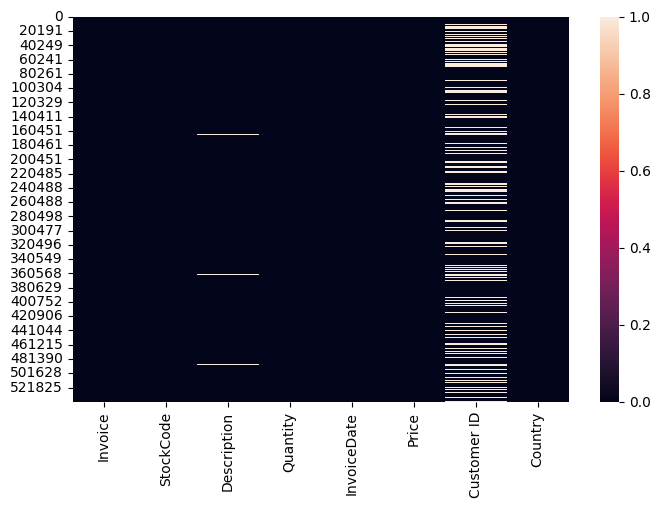

In [8]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),)
plt.show()


In [9]:
df=df.dropna(subset="Customer ID")

In [10]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [11]:
# Remove cancelled orders
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove records with Quantity <= 0
df = df[df["Quantity"] > 0]

# Remove records with Price <= 0
df = df[df["Price"] > 0]



# Reset index
df = df.reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (392693, 8)


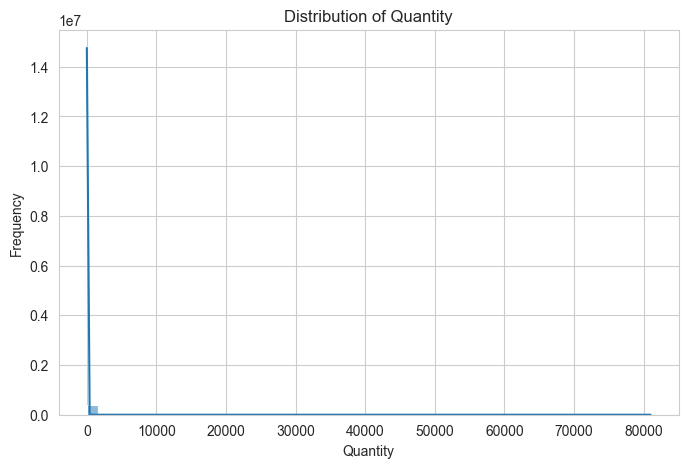

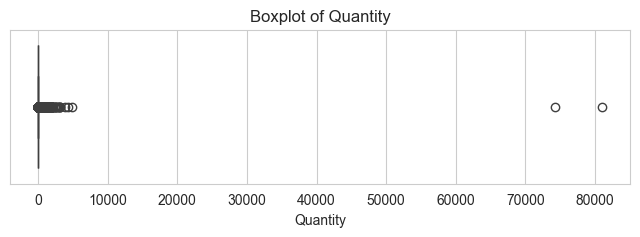

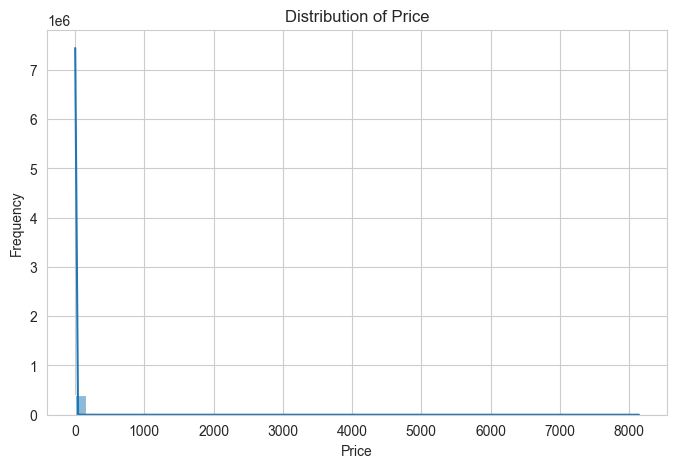

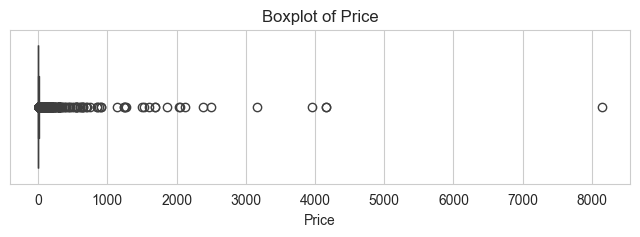

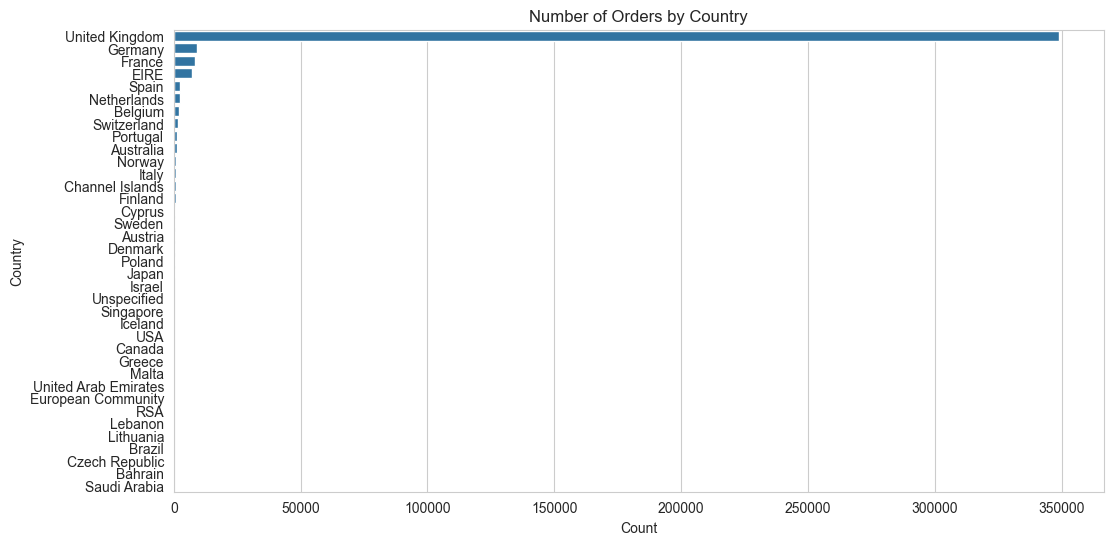

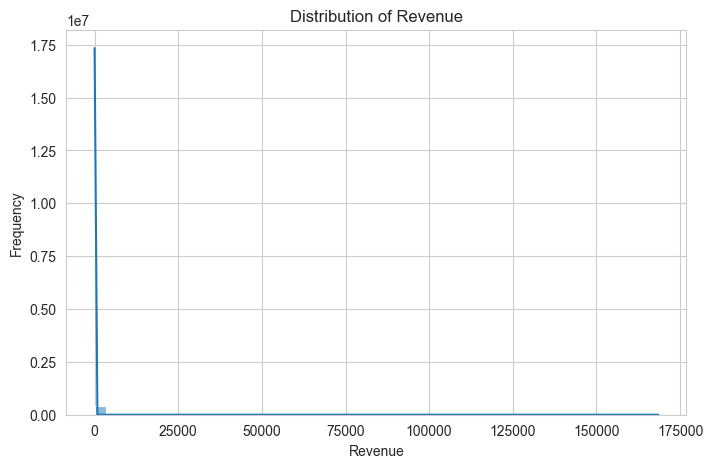

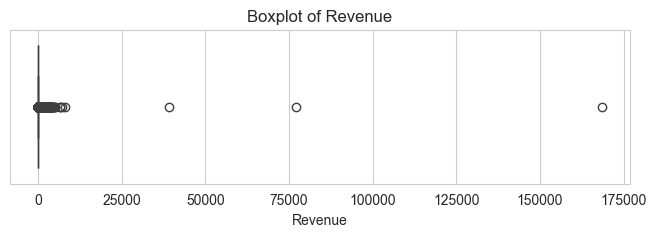


Summary Statistics
            Quantity          Price        Revenue
count  392693.000000  392693.000000  392693.000000
mean       13.119671       3.125952      22.631488
std       180.492603      22.241820     311.098828
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000


In [12]:


# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


# Create Revenue Column

df["Revenue"] = df["Quantity"] * df["Price"]


# Quantity Distribution


# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=50, kde=True)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Quantity"])
plt.title("Boxplot of Quantity")
plt.show()



# Price Distribution

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Price")
plt.show()



# Country Distribution


plt.figure(figsize=(12,6))
sns.countplot(
    y="Country",
    data=df,
    order=df["Country"].value_counts().index
)

plt.title("Number of Orders by Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()



# Revenue Distribution

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df["Revenue"], bins=50, kde=True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Revenue"])
plt.title("Boxplot of Revenue")
plt.show()



# Summary Statistics


print("\nSummary Statistics")
print(df[["Quantity", "Price", "Revenue"]].describe())

In [12]:
df['Revenue']=df['Quantity']*df['Price']

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


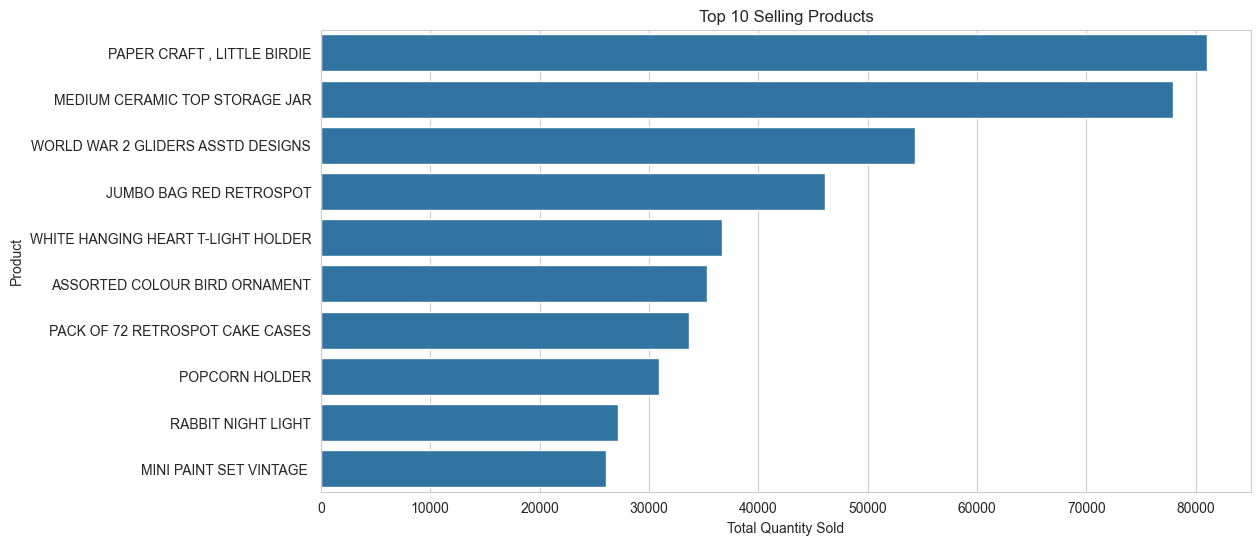

In [13]:
top_selling = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_selling)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_selling.values,
    y=top_selling.index
)

plt.title("Top 10 Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()

In [13]:
highest_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      
)

print(highest_revenue)

# plt.figure(figsize=(12,6))
# sns.barplot(
#     x=highest_revenue.values,
#     y=highest_revenue.index
# )

# plt.title("Top 10 Highest Revenue Products")
# plt.xlabel("Revenue")
# plt.ylabel("Product")
# plt.show()

Description
PAPER CRAFT , LITTLE BIRDIE           168469.600
REGENCY CAKESTAND 3 TIER              142264.750
WHITE HANGING HEART T-LIGHT HOLDER    100392.100
JUMBO BAG RED RETROSPOT                85040.540
MEDIUM CERAMIC TOP STORAGE JAR         81416.730
                                         ...    
PURPLE FRANGIPANI HAIRCLIP                 0.850
VINTAGE BLUE TINSEL REEL                   0.840
SET 12 COLOURING PENCILS DOILEY            0.650
HEN HOUSE W CHICK IN NEST                  0.420
PADS TO MATCH ALL CUSHIONS                 0.003
Name: Revenue, Length: 3877, dtype: float64


In [14]:
most_expensive = (
    df.groupby("Description")["Price"]
      .max()
      .sort_values(ascending=False)
      
)

print(most_expensive)

# plt.figure(figsize=(12,6))
# sns.barplot(
#     x=most_expensive.values,
#     y=most_expensive.index
# )

# plt.title("Top 10 Most Expensive Products")
# plt.xlabel("Maximum Price")
# plt.ylabel("Product")
# plt.show()

Description
POSTAGE                           8142.750
Manual                            4161.060
DOTCOM POSTAGE                    1599.260
PICNIC BASKET WICKER 60 PIECES     649.500
VINTAGE RED KITCHEN CABINET        295.000
                                    ...   
MINI HIGHLIGHTER PENS                0.120
POPART WOODEN PENCILS ASST           0.120
PORCELAIN BUDAH INCENSE HOLDER       0.100
WRAP BAD HAIR DAY                    0.100
PADS TO MATCH ALL CUSHIONS           0.001
Name: Price, Length: 3877, dtype: float64


In [15]:
least_sold = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values()
      
)

print(least_sold)

# plt.figure(figsize=(12,6))
# sns.barplot(
#     x=least_sold.values,
#     y=least_sold.index
# )

# plt.title("Least Sold Products")
# plt.xlabel("Quantity Sold")
# plt.ylabel("Product")
# plt.show()

Description
CRACKED GLAZE EARRINGS RED                 1
CRACKED GLAZE EARRINGS BROWN               1
WHITE ROSEBUD  PEARL EARRINGS              1
MIDNIGHT BLUE CRYSTAL DROP EARRINGS        1
BLUE PADDED SOFT MOBILE                    1
                                       ...  
WHITE HANGING HEART T-LIGHT HOLDER     36706
JUMBO BAG RED RETROSPOT                46078
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54319
MEDIUM CERAMIC TOP STORAGE JAR         77916
PAPER CRAFT , LITTLE BIRDIE            80995
Name: Quantity, Length: 3877, dtype: int64


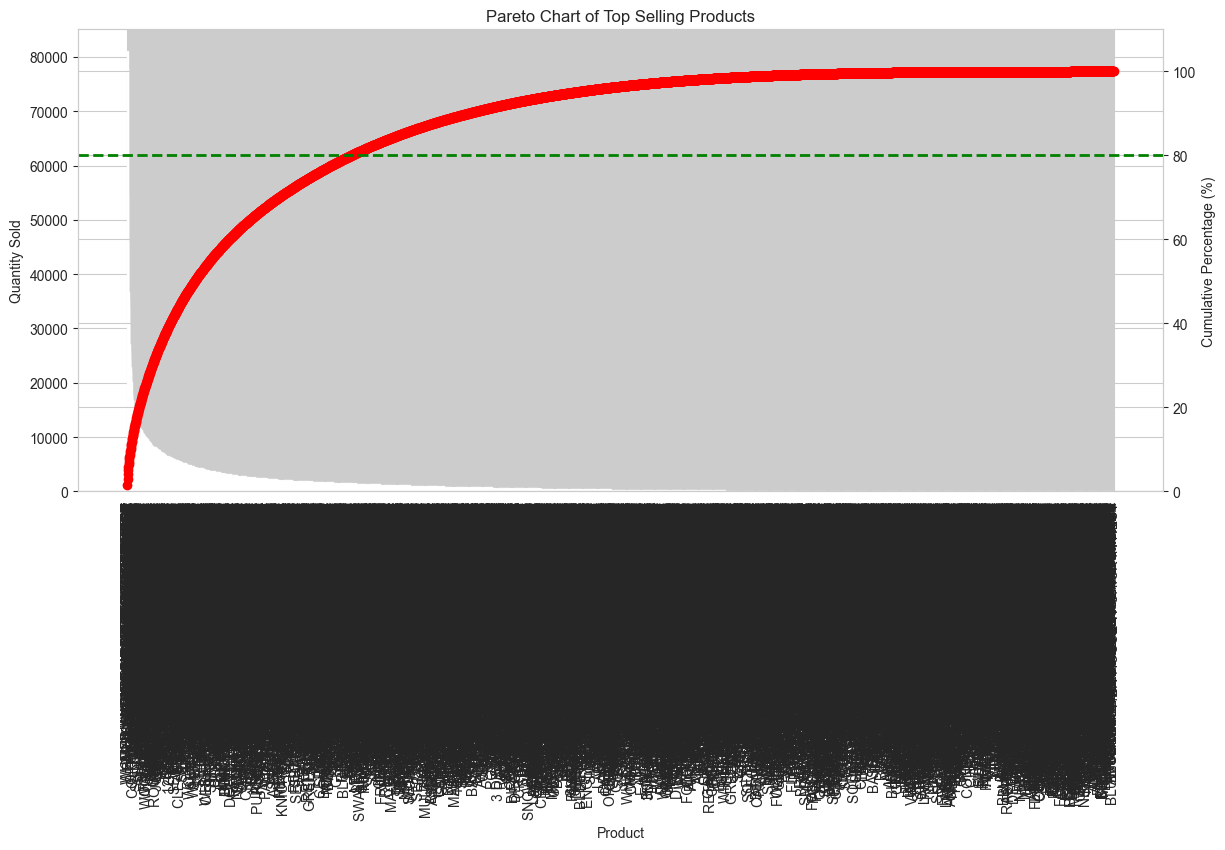

In [17]:
pareto = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      
)

cum_percentage = pareto.cumsum() / pareto.sum() * 100

fig, ax1 = plt.subplots(figsize=(14,6))

# Bar Plot
ax1.bar(pareto.index, pareto.values)
ax1.set_ylabel("Quantity Sold")
ax1.set_xlabel("Product")
ax1.tick_params(axis='x', rotation=90)

# Line Plot
ax2 = ax1.twinx()
ax2.plot(
    pareto.index,
    cum_percentage,
    color='red',
    marker='o'
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0,110)

# 80% Reference Line
ax2.axhline(
    y=80,
    color='green',
    linestyle='--',
    linewidth=2
)

plt.title("Pareto Chart of Top Selling Products")
plt.show()

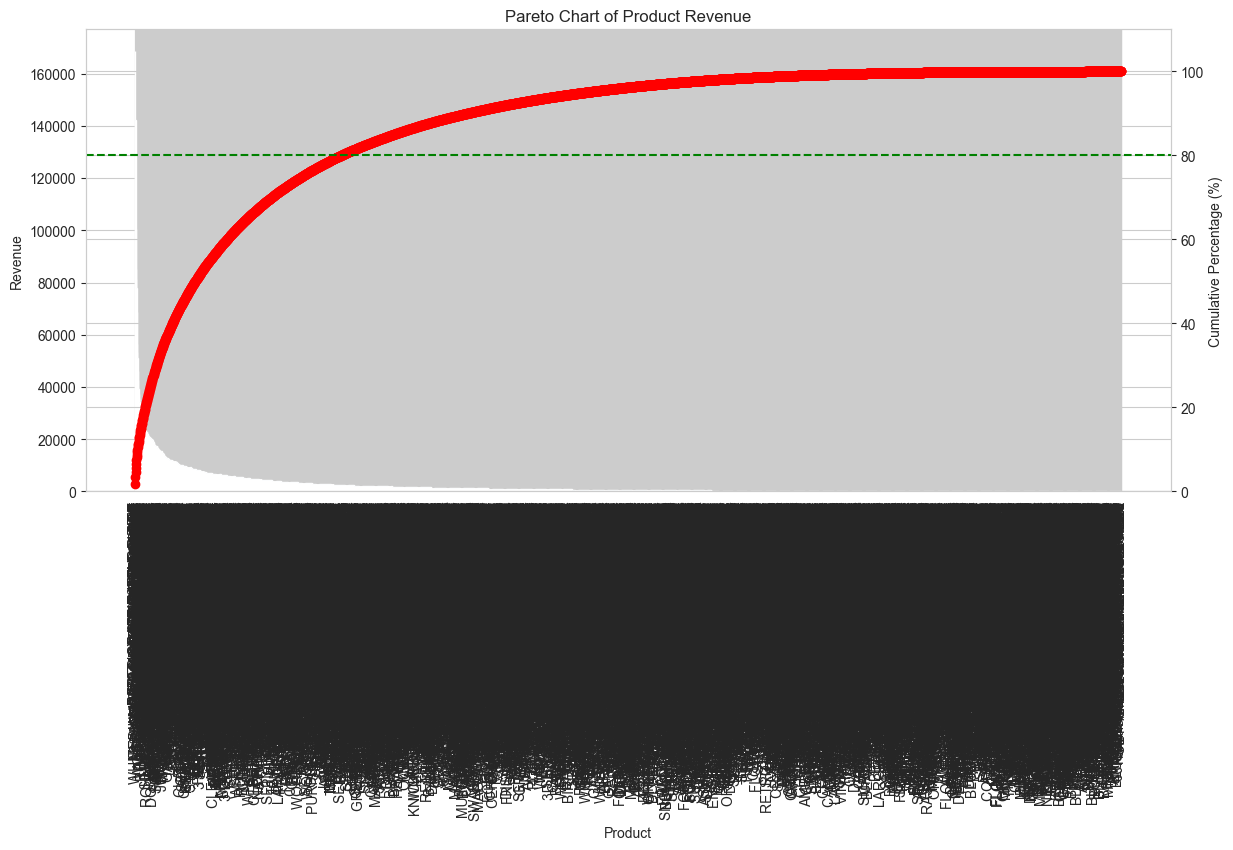

In [18]:
pareto_rev = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      
)

cum_rev = pareto_rev.cumsum() / pareto_rev.sum() * 100

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    pareto_rev.index,
    pareto_rev.values
)

ax1.set_ylabel("Revenue")
ax1.set_xlabel("Product")
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto_rev.index,
    cum_rev,
    color='red',
    marker='o'
)

ax2.axhline(
    y=80,
    color='green',
    linestyle='--'
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0,110)

plt.title("Pareto Chart of Product Revenue")
plt.show()

Top Customers
Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


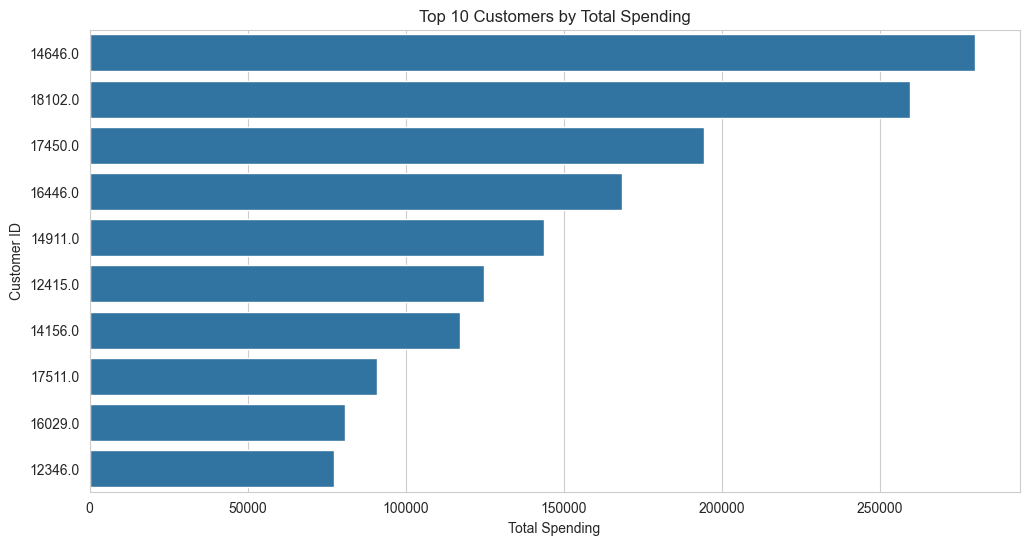

In [19]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Top Customers")
print(top_customers.head(10))

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_customers.head(10).values,
    y=top_customers.head(10).index.astype(str)
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.show()

Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


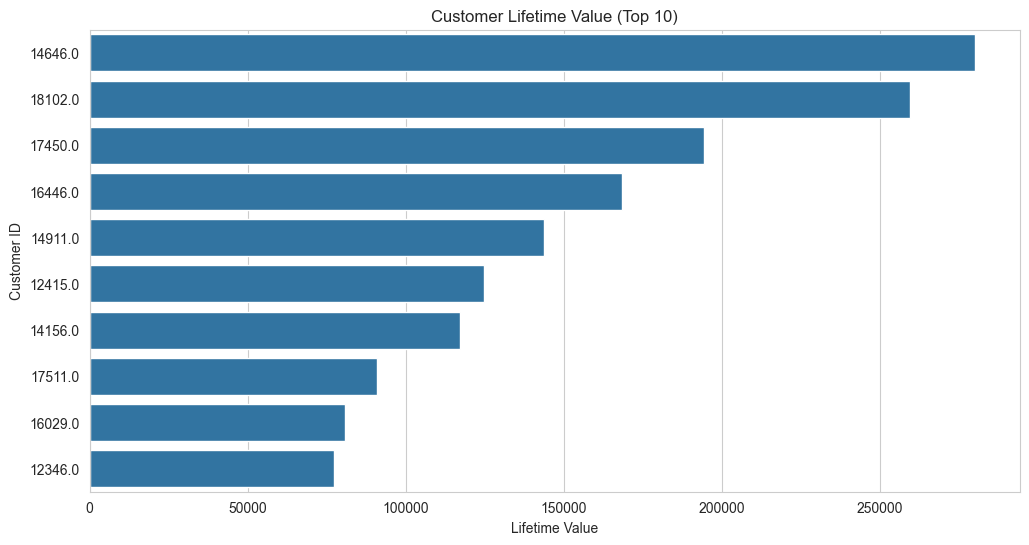

In [20]:
customer_ltv = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(customer_ltv.head(10))
plt.figure(figsize=(12,6))
sns.barplot(
    x=customer_ltv.head(10).values,
    y=customer_ltv.head(10).index.astype(str)
)

plt.title("Customer Lifetime Value (Top 10)")
plt.xlabel("Lifetime Value")
plt.ylabel("Customer ID")
plt.show()

In [21]:
invoice_revenue = (
    df.groupby("Invoice")["Revenue"]
      .sum()
)

average_order_value = invoice_revenue.mean()

print(f"Average Order Value : {average_order_value:.2f}")

Average Order Value : 479.56


Customer ID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: Invoice, dtype: int64


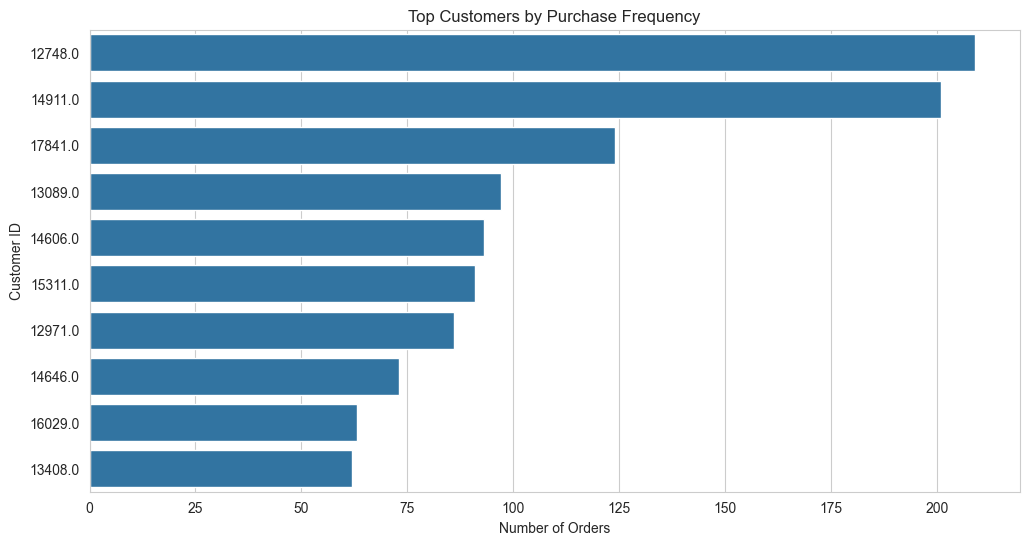

In [22]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
)

print(purchase_frequency.head(10))
plt.figure(figsize=(12,6))
sns.barplot(
    x=purchase_frequency.head(10).values,
    y=purchase_frequency.head(10).index.astype(str)
)

plt.title("Top Customers by Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.show()

In [23]:
customer_metrics = (
    df.groupby("Customer ID")
      .agg(
          Total_Spending=("Revenue","sum"),
          Total_Orders=("Invoice","nunique"),
          Total_Items=("Quantity","sum")
      )
)

customer_metrics["Average_Basket_Size"] = (
    customer_metrics["Total_Items"] /
    customer_metrics["Total_Orders"]
)

customer_metrics["Average_Order_Value"] = (
    customer_metrics["Total_Spending"] /
    customer_metrics["Total_Orders"]
)

customer_metrics = customer_metrics.sort_values(
    by="Total_Spending",
    ascending=False
)

print(customer_metrics.head(10))

             Total_Spending  Total_Orders  Total_Items  Average_Basket_Size  \
Customer ID                                                                   
14646.0           280206.02            73       196915          2697.465753   
18102.0           259657.30            60        64124          1068.733333   
17450.0           194390.79            46        69973          1521.152174   
16446.0           168472.50             2        80997         40498.500000   
14911.0           143711.17           201        80240           399.203980   
12415.0           124914.53            21        77374          3684.476190   
14156.0           117210.08            55        57768          1050.327273   
17511.0            91062.38            31        64549          2082.225806   
16029.0            80850.84            63        40108           636.634921   
12346.0            77183.60             1        74215         74215.000000   

             Average_Order_Value  
Customer ID     

In [24]:
print(customer_metrics.describe())

       Total_Spending  Total_Orders    Total_Items  Average_Basket_Size  \
count     4338.000000   4338.000000    4338.000000           4338.00000   
mean      2048.692230      4.272015    1187.644767            252.46295   
std       8985.229676      7.697998    5043.619620           1312.76933   
min          3.750000      1.000000       1.000000              1.00000   
25%        306.482500      1.000000     159.000000             92.00000   
50%        668.570000      2.000000     378.000000            161.00000   
75%       1660.597500      5.000000     989.750000            270.00000   
max     280206.020000    209.000000  196915.000000          74215.00000   

       Average_Order_Value  
count          4338.000000  
mean            417.646772  
std            1796.511228  
min               3.450000  
25%             177.867083  
50%             291.940000  
75%             428.280625  
max           84236.250000  


Countries by Quantity Sold
Country
United Kingdom          4241305
Netherlands              200361
EIRE                     140133
Germany                  119154
France                   111429
Australia                 83891
Sweden                    36078
Switzerland               30082
Spain                     27933
Japan                     26016
Belgium                   23237
Norway                    19336
Portugal                  16095
Finland                   10704
Channel Islands            9485
Denmark                    8235
Italy                      8112
Cyprus                     6340
Singapore                  5241
Austria                    4881
Israel                     4043
Poland                     3684
Canada                     2763
Iceland                    2458
USA                        2458
Unspecified                1785
Greece                     1557
United Arab Emirates        982
Malta                       970
Czech Republic              671
Lithu

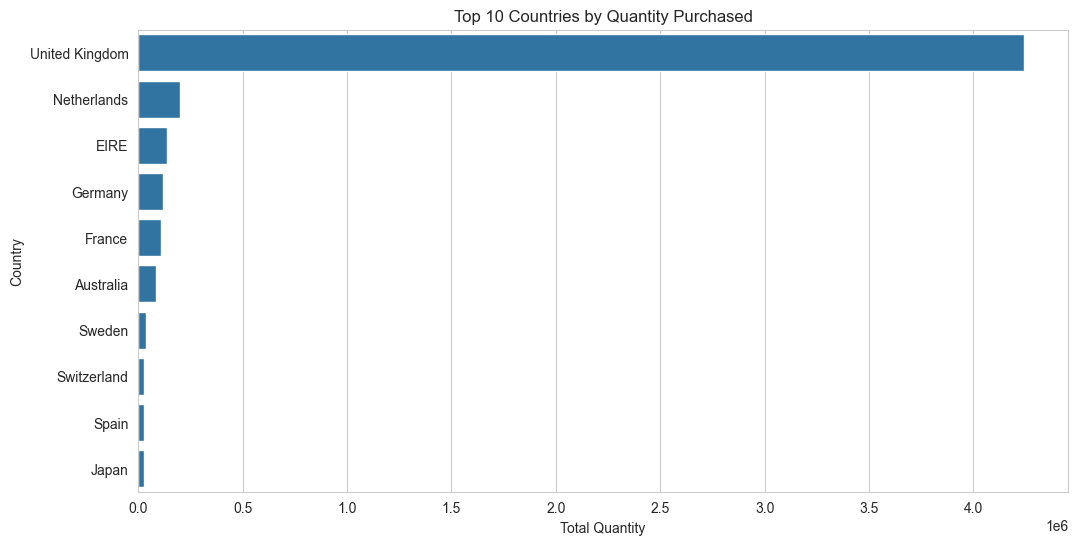

In [25]:
country_quantity = (
    df.groupby("Country")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print("Countries by Quantity Sold")
print(country_quantity)

plt.figure(figsize=(12,6))
sns.barplot(
    x=country_quantity.head(10).values,
    y=country_quantity.head(10).index
)

plt.title("Top 10 Countries by Quantity Purchased")
plt.xlabel("Total Quantity")
plt.ylabel("Country")
plt.show()

Countries by Revenue
Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208952.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590

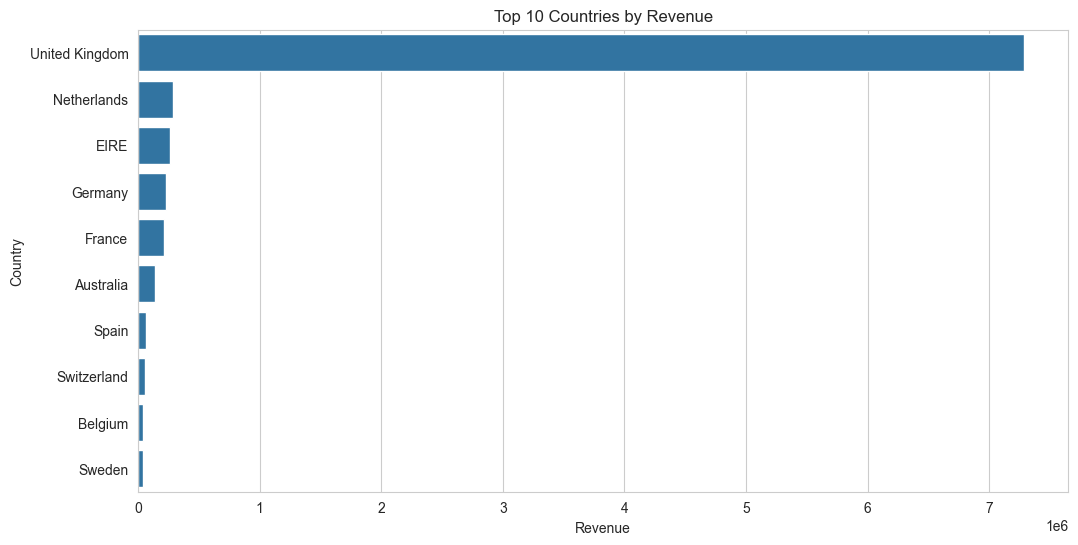

In [26]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print("Countries by Revenue")
print(country_revenue)

plt.figure(figsize=(12,6))
sns.barplot(
    x=country_revenue.head(10).values,
    y=country_revenue.head(10).index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

Average Order Value by Country
Country
Singapore               3039.898571
Netherlands             3036.663191
Australia               2429.014211
Japan                   1969.282632
Lebanon                 1693.880000
Israel                  1443.168000
Brazil                  1143.600000
Switzerland             1106.744118
Sweden                  1065.773056
Denmark                 1053.074444
EIRE                    1020.240231
Norway                  1004.595556
RSA                     1002.310000
Greece                   952.104000
Cyprus                   843.928125
Channel Islands          786.174615
USA                      716.078000
Spain                    683.984000
United Arab Emirates     634.093333
Iceland                  615.714286
Canada                   611.063333
Austria                  599.922353
Portugal                 585.541053
Finland                  549.904390
Malta                    545.118000
France                   537.152468
Germany                  

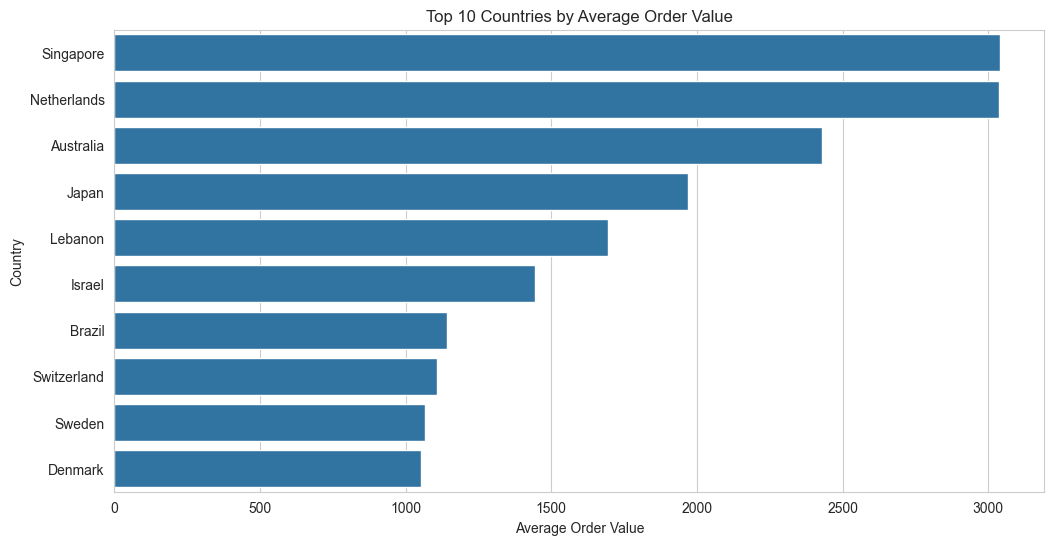

In [27]:
invoice_country = (
    df.groupby(["Country", "Invoice"])["Revenue"]
      .sum()
      .reset_index()
)

country_aov = (
    invoice_country.groupby("Country")["Revenue"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Order Value by Country")
print(country_aov)
plt.figure(figsize=(12,6))
sns.barplot(
    x=country_aov.head(10).values,
    y=country_aov.head(10).index
)

plt.title("Top 10 Countries by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Country")
plt.show()

In [28]:
country_summary = (
    df.groupby("Country")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Total_Orders=("Invoice", "nunique"),
          Total_Customers=("Customer ID", "nunique")
      )
)

country_summary["Average_Order_Value"] = (
    country_summary["Total_Revenue"] /
    country_summary["Total_Orders"]
)

country_summary = country_summary.sort_values(
    by="Total_Revenue",
    ascending=False
)

print(country_summary)

                      Total_Quantity  Total_Revenue  Total_Orders  \
Country                                                             
United Kingdom               4241305    7285024.644         16646   
Netherlands                   200361     285446.340            94   
EIRE                          140133     265262.460           260   
Germany                       119154     228678.400           457   
France                        111429     208952.310           389   
Australia                      83891     138453.810            57   
Spain                          27933      61558.560            90   
Switzerland                    30082      56443.950            51   
Belgium                        23237      41196.340            98   
Sweden                         36078      38367.830            36   
Japan                          26016      37416.370            19   
Norway                         19336      36165.440            36   
Portugal                       160

In [29]:
print(country_summary.head(10))

                Total_Quantity  Total_Revenue  Total_Orders  Total_Customers  \
Country                                                                        
United Kingdom         4241305    7285024.644         16646             3920   
Netherlands             200361     285446.340            94                9   
EIRE                    140133     265262.460           260                3   
Germany                 119154     228678.400           457               94   
France                  111429     208952.310           389               87   
Australia                83891     138453.810            57                9   
Spain                    27933      61558.560            90               30   
Switzerland              30082      56443.950            51               21   
Belgium                  23237      41196.340            98               25   
Sweden                   36078      38367.830            36                8   

                Average_Order_Value  
C

In [30]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

C:\Users\User\AppData\Local\Temp\ipykernel_17032\3012402086.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [31]:
#Create Time Features
# Year
df["Year"] = df["InvoiceDate"].dt.year

# Month Number
df["Month"] = df["InvoiceDate"].dt.month

# Month Name
df["Month_Name"] = df["InvoiceDate"].dt.month_name()

# Week Number
df["Week"] = df["InvoiceDate"].dt.isocalendar().week

# Day Name
df["Day"] = df["InvoiceDate"].dt.day_name()

# Hour
df["Hour"] = df["InvoiceDate"].dt.hour

# Quarter
df["Quarter"] = df["InvoiceDate"].dt.quarter

# Weekend
df["Weekend"] = df["Day"].isin(["Saturday", "Sunday"])
print(df.head(5))

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  Revenue  Year  \
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom    15.30  2010   
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom    20.34  2010   
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom    22.00  2010   
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom    20.34  2010   
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom    20.34  2010   

   Month Month_Name  Week        Day  Hour  Quarter  Weekend  
0     12   December    48  Wednesday     8        4    Fals

Year
2010     311048
2011    4840955
Name: Quantity, dtype: int64


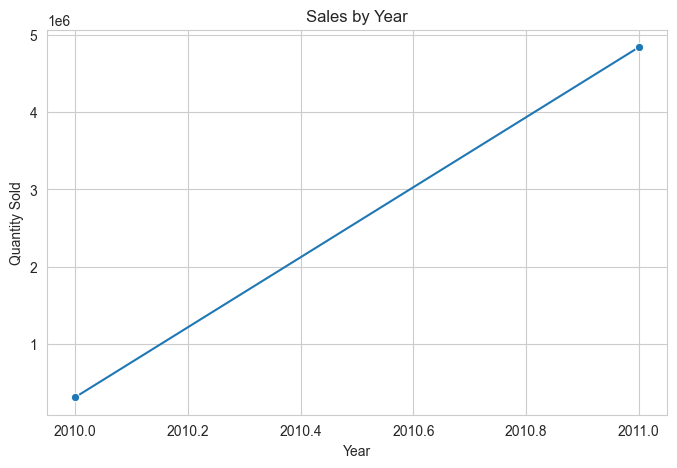

In [32]:
#Sales by Year
sales_year = (
    df.groupby("Year")["Quantity"]
      .sum()
)

print(sales_year)

plt.figure(figsize=(8,5))
sns.lineplot(
    x=sales_year.index,
    y=sales_year.values,
    marker="o"
)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Quantity Sold")
plt.show()

Month_Name
January      348473
February     265027
March        347582
April        291366
May          372864
June         363014
July         367360
August       397373
September    543652
October      591543
November     665923
December     597826
Name: Quantity, dtype: int64


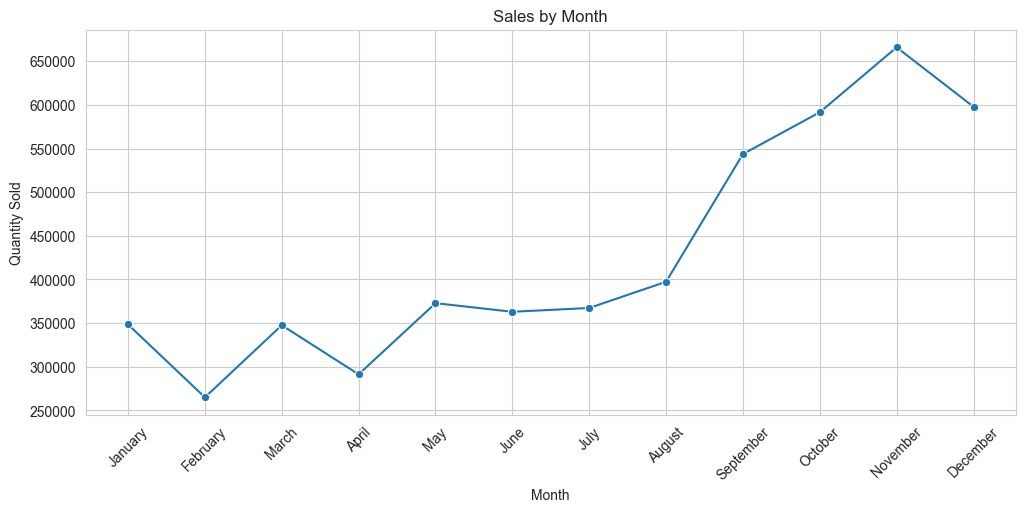

In [33]:
#Sales by Month
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

sales_month = (
    df.groupby("Month_Name")["Quantity"]
      .sum()
      .reindex(month_order)
)

print(sales_month)

plt.figure(figsize=(12,5))
sns.lineplot(
    x=sales_month.index,
    y=sales_month.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.show()

Day
Monday        766911.0
Tuesday      1005760.0
Wednesday     960082.0
Thursday     1149619.0
Friday        808649.0
Saturday           NaN
Sunday        460982.0
Name: Quantity, dtype: float64


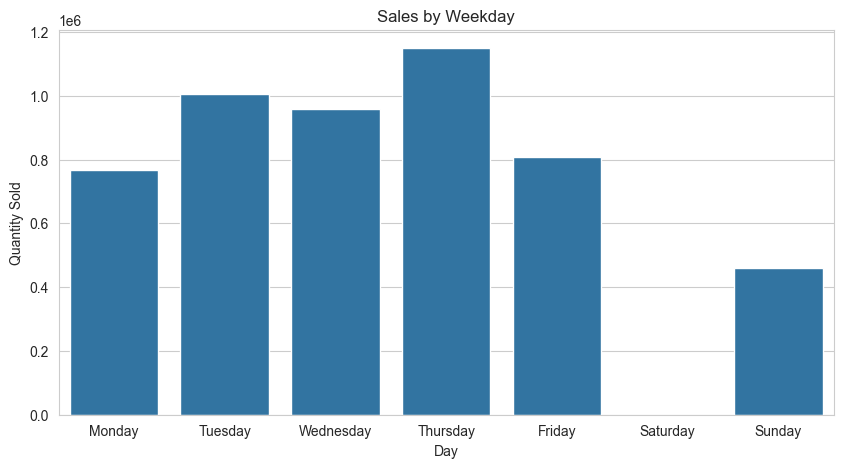

In [34]:
#Sales by Weekday
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

sales_day = (
    df.groupby("Day")["Quantity"]
      .sum()
      .reindex(day_order)
)

print(sales_day)

plt.figure(figsize=(10,5))
sns.barplot(
    x=sales_day.index,
    y=sales_day.values
)

plt.title("Sales by Weekday")
plt.xlabel("Day")
plt.ylabel("Quantity Sold")
plt.show()

Hour
6          1
7      15370
8     157815
9     482216
10    774799
11    645056
12    822369
13    680275
14    555896
15    539004
16    253158
17    129136
18     54899
19     32501
20      9508
Name: Quantity, dtype: int64


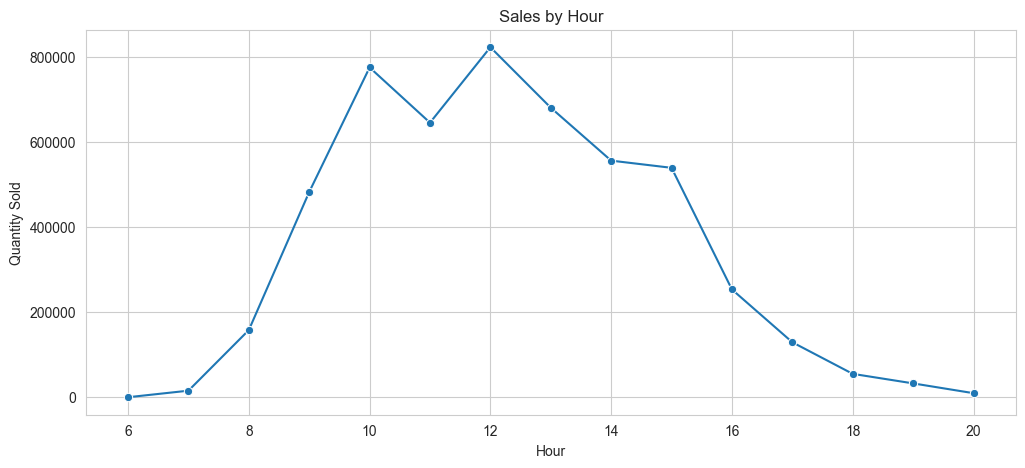

In [35]:
#: Sales by Hour
sales_hour = (
    df.groupby("Hour")["Quantity"]
      .sum()
)

print(sales_hour)

plt.figure(figsize=(12,5))
sns.lineplot(
    x=sales_hour.index,
    y=sales_hour.values,
    marker="o"
)

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Quantity Sold")
plt.show()

Month_Name
January       568101.310
February      446084.920
March         594081.760
April         468374.331
May           677355.150
June          660046.050
July          598962.901
August        644051.040
September     950690.202
October      1035642.450
November     1156205.610
December     1087631.170
Name: Revenue, dtype: float64


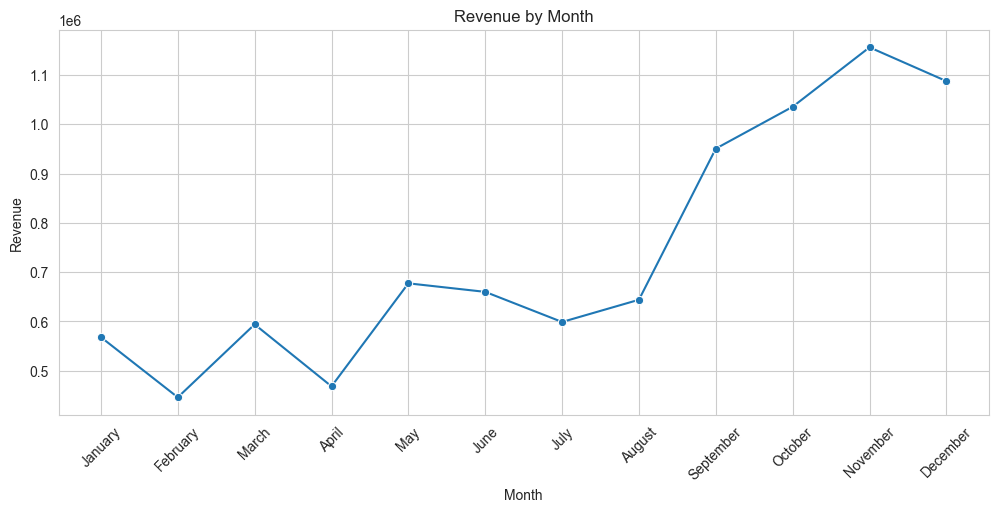

In [36]:
#Revenue by Month
revenue_month = (
    df.groupby("Month_Name")["Revenue"]
      .sum()
      .reindex(month_order)
)

print(revenue_month)

plt.figure(figsize=(12,5))
sns.lineplot(
    x=revenue_month.index,
    y=revenue_month.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Quarter
1    1608267.990
2    1805775.531
3    2193704.143
4    3279479.230
Name: Revenue, dtype: float64


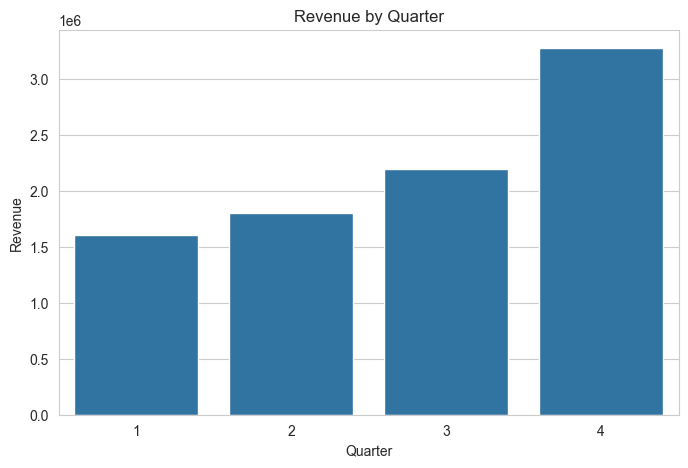

In [37]:
#Quarterly Revenue
quarterly_revenue = (
    df.groupby("Quarter")["Revenue"]
      .sum()
)

print(quarterly_revenue)

plt.figure(figsize=(8,5))
sns.barplot(
    x=quarterly_revenue.index,
    y=quarterly_revenue.values
)

plt.title("Revenue by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.show()

Weekend
False    8101736.573
True      785490.321
Name: Revenue, dtype: float64


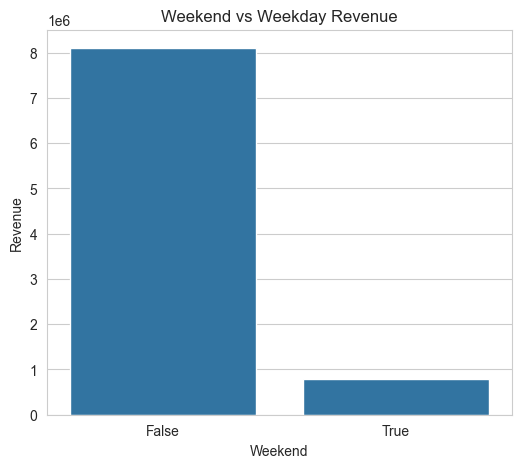

In [38]:
#Weekend vs Weekday Sales
weekend_sales = (
    df.groupby("Weekend")["Revenue"]
      .sum()
)

print(weekend_sales)

plt.figure(figsize=(6,5))
sns.barplot(
    x=weekend_sales.index,
    y=weekend_sales.values
)

plt.title("Weekend vs Weekday Revenue")
plt.xlabel("Weekend")
plt.ylabel("Revenue")
plt.show()

In [39]:
#Summary Table
print("Sales by Year")
print(sales_year)

print("\nSales by Month")
print(sales_month)

print("\nSales by Weekday")
print(sales_day)

print("\nSales by Hour")
print(sales_hour)

print("\nRevenue by Month")
print(revenue_month)

Sales by Year
Year
2010     311048
2011    4840955
Name: Quantity, dtype: int64

Sales by Month
Month_Name
January      348473
February     265027
March        347582
April        291366
May          372864
June         363014
July         367360
August       397373
September    543652
October      591543
November     665923
December     597826
Name: Quantity, dtype: int64

Sales by Weekday
Day
Monday        766911.0
Tuesday      1005760.0
Wednesday     960082.0
Thursday     1149619.0
Friday        808649.0
Saturday           NaN
Sunday        460982.0
Name: Quantity, dtype: float64

Sales by Hour
Hour
6          1
7      15370
8     157815
9     482216
10    774799
11    645056
12    822369
13    680275
14    555896
15    539004
16    253158
17    129136
18     54899
19     32501
20      9508
Name: Quantity, dtype: int64

Revenue by Month
Month_Name
January       568101.310
February      446084.920
March         594081.760
April         468374.331
May           677355.150
June        

In [40]:
#Select Numerical Columns
numeric = df.select_dtypes(include="number")

print(numeric.columns)

Index(['Quantity', 'Price', 'Customer ID', 'Revenue', 'Year', 'Month', 'Week',
       'Hour', 'Quarter'],
      dtype='object')


In [41]:
#Correlation Matrix
correlation_matrix = numeric.corr()

print(correlation_matrix)

             Quantity     Price  Customer ID   Revenue      Year     Month  \
Quantity     1.000000 -0.004578    -0.006029  0.914451  0.001469 -0.004040   
Price       -0.004578  1.000000    -0.010802  0.081619 -0.000202 -0.005060   
Customer ID -0.006029 -0.010802     1.000000 -0.003897 -0.035671  0.029658   
Revenue      0.914451  0.081619    -0.003897  1.000000  0.000349 -0.002562   
Year         0.001469 -0.000202    -0.035671  0.000349  1.000000 -0.340597   
Month       -0.004040 -0.005060     0.029658 -0.002562 -0.340597  1.000000   
Week        -0.004019 -0.005106     0.029243 -0.002612 -0.326248  0.996301   
Hour        -0.014665 -0.000217     0.065808 -0.013093 -0.019772  0.058441   
Quarter     -0.004208 -0.004432     0.026735 -0.003157 -0.270612  0.971941   

                 Week      Hour   Quarter  
Quantity    -0.004019 -0.014665 -0.004208  
Price       -0.005106 -0.000217 -0.004432  
Customer ID  0.029243  0.065808  0.026735  
Revenue     -0.002612 -0.013093 -0.003157  

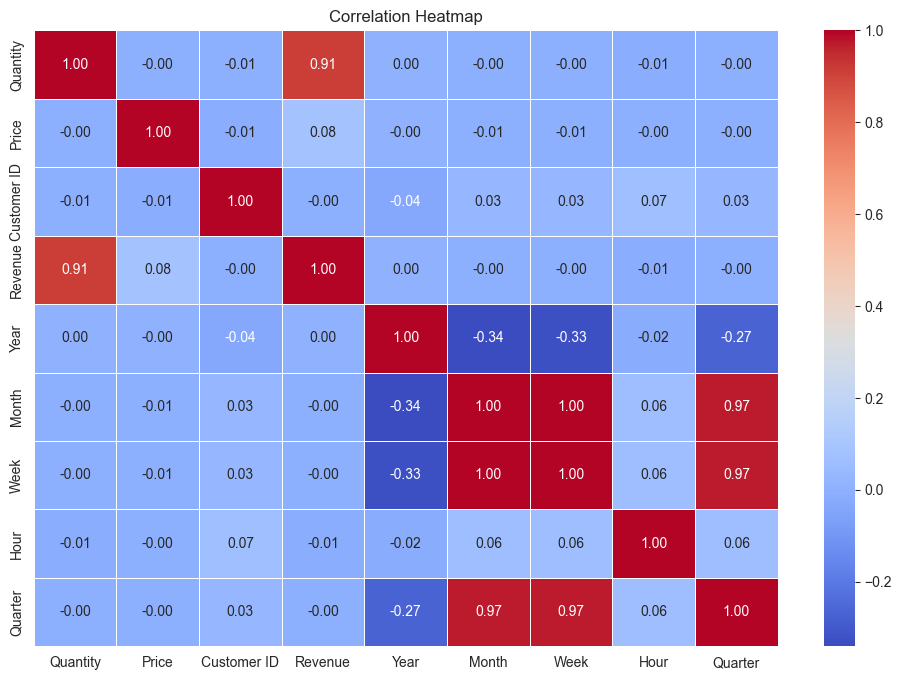

In [42]:
#Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Revenue        1.000000
Quantity       0.914451
Price          0.081619
Year           0.000349
Month         -0.002562
Week          -0.002612
Quarter       -0.003157
Customer ID   -0.003897
Hour          -0.013093
Name: Revenue, dtype: float64


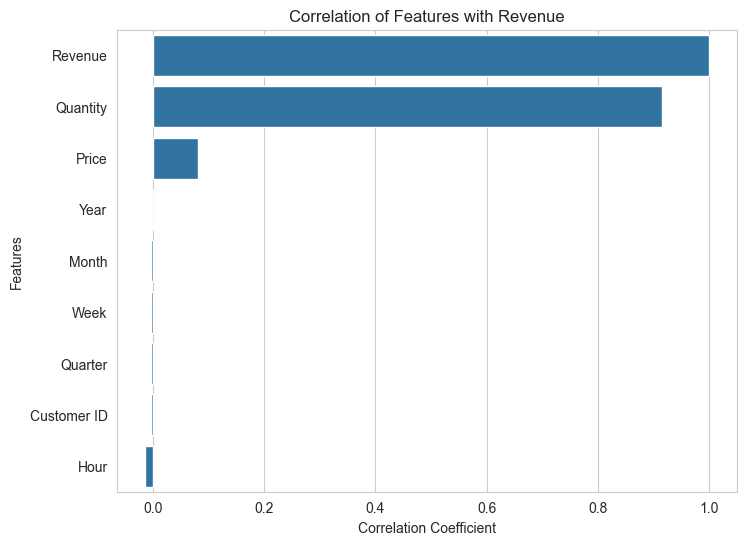

In [43]:
#Correlation with Revenue
revenue_corr = (
    correlation_matrix["Revenue"]
    .sort_values(ascending=False)
)

print(revenue_corr)



plt.figure(figsize=(8,6))

sns.barplot(
    x=revenue_corr.values,
    y=revenue_corr.index
)

plt.title("Correlation of Features with Revenue")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

In [44]:
#Highly Correlated Features

threshold = 0.8

high_corr = correlation_matrix.where(
    abs(correlation_matrix) > threshold
)

print(high_corr)

             Quantity  Price  Customer ID   Revenue  Year     Month      Week  \
Quantity     1.000000    NaN          NaN  0.914451   NaN       NaN       NaN   
Price             NaN    1.0          NaN       NaN   NaN       NaN       NaN   
Customer ID       NaN    NaN          1.0       NaN   NaN       NaN       NaN   
Revenue      0.914451    NaN          NaN  1.000000   NaN       NaN       NaN   
Year              NaN    NaN          NaN       NaN   1.0       NaN       NaN   
Month             NaN    NaN          NaN       NaN   NaN  1.000000  0.996301   
Week              NaN    NaN          NaN       NaN   NaN  0.996301  1.000000   
Hour              NaN    NaN          NaN       NaN   NaN       NaN       NaN   
Quarter           NaN    NaN          NaN       NaN   NaN  0.971941  0.970446   

             Hour   Quarter  
Quantity      NaN       NaN  
Price         NaN       NaN  
Customer ID   NaN       NaN  
Revenue       NaN       NaN  
Year          NaN       NaN  
Month    

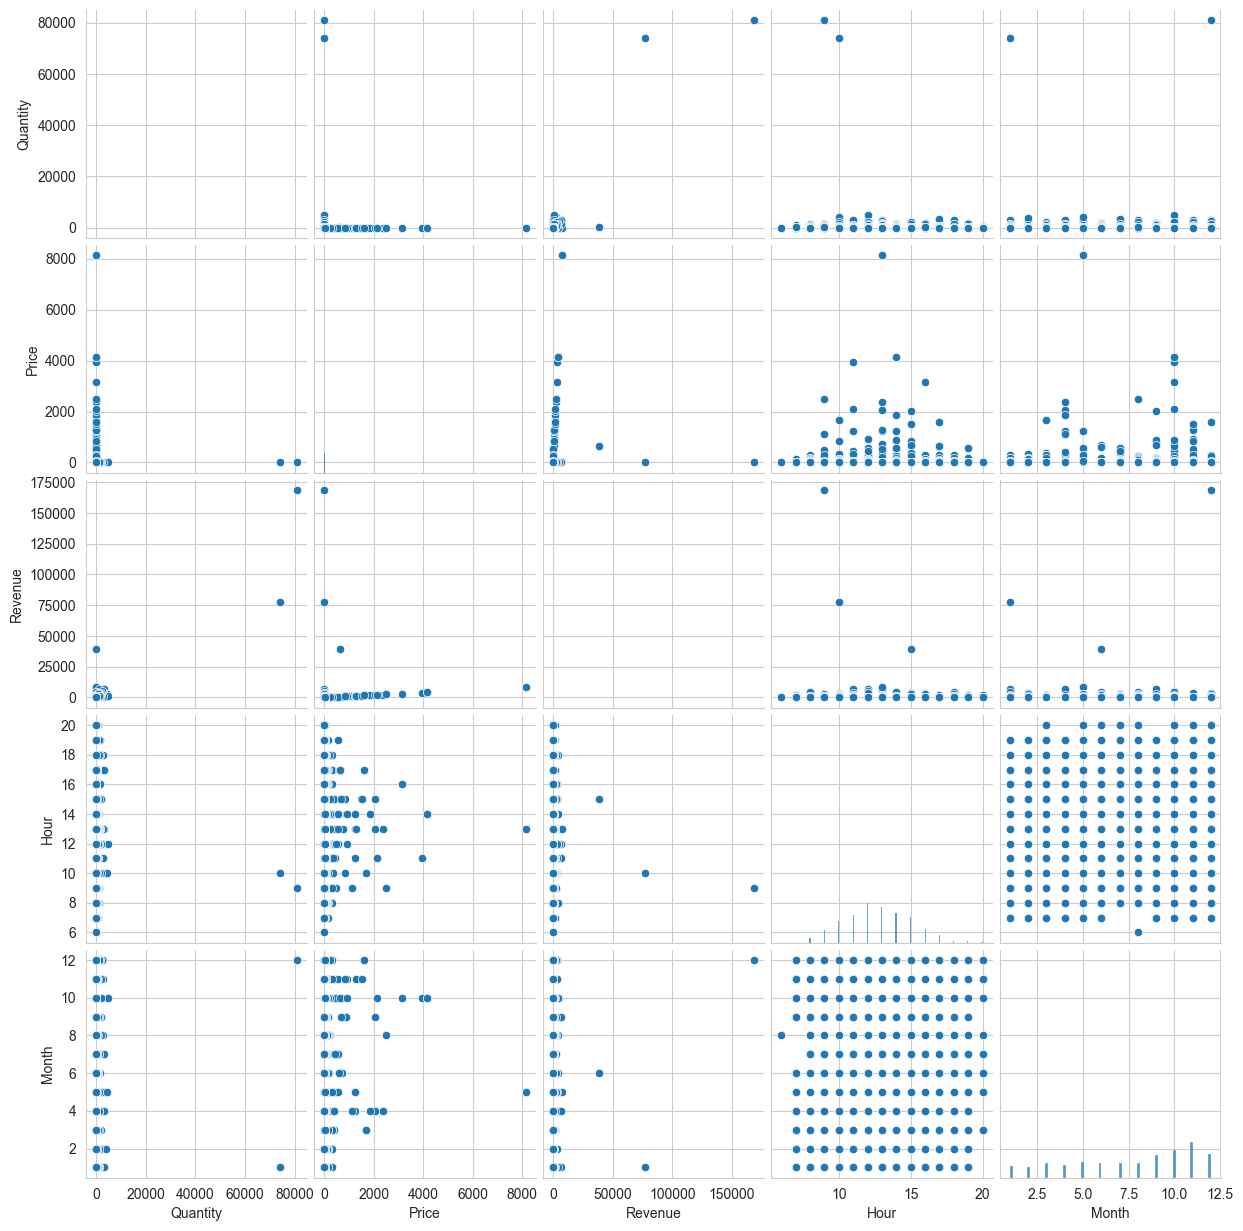

In [45]:
#pairplot
sns.pairplot(
    df[
        [
            "Quantity",
            "Price",
            "Revenue",
            "Hour",
            "Month"
        ]
    ]
)

plt.show()

In [46]:
numeric = df.select_dtypes(include="number").drop(columns=["Customer ID"])

In [47]:
numeric


,Quantity,Price,Revenue,Year,Month,Week,Hour,Quarter
0,6,2.55,15.30,2010,12,48,8,4
1,6,3.39,20.34,2010,12,48,8,4
2,8,2.75,22.00,2010,12,48,8,4
3,6,3.39,20.34,2010,12,48,8,4
4,6,3.39,20.34,2010,12,48,8,4
...,...,...,...,...,...,...,...,...
392688,6,2.10,12.60,2011,12,49,12,4
392689,4,4.15,16.60,2011,12,49,12,4
392690,4,4.15,16.60,2011,12,49,12,4
392691,3,4.95,14.85,2011,12,49,12,4


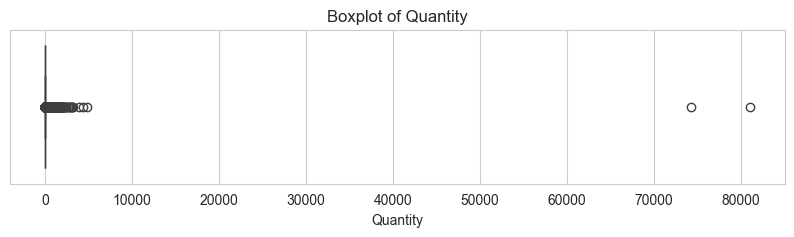

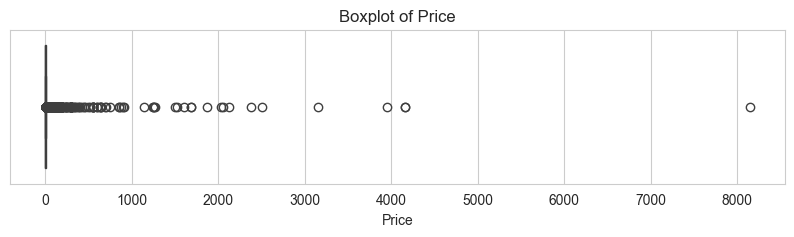

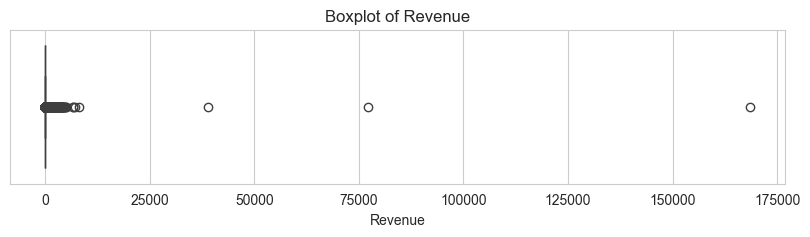

In [48]:
#Boxplots
#Quantity
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")
plt.show()
#Price
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Price")
plt.show()
#Revenue
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Revenue"])

plt.title("Boxplot of Revenue")
plt.show()

In [49]:
#IQR Method
#Quantity
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

quantity_outliers = df[
    (df["Quantity"] < lower) |
    (df["Quantity"] > upper)
]

print("Quantity Outliers:", len(quantity_outliers))
quantity_outliers.head()


Quantity Outliers: 25616


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Week,Day,Hour,Quarter,Weekend
13,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,December,48,Wednesday,8,4,False
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,2010,12,December,48,Wednesday,8,4,False
44,536370,22492,MINI PAINT SET VINTAGE,36,2010-12-01 08:45:00,0.65,12583.0,France,23.40,2010,12,December,48,Wednesday,8,4,False
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.00,2010,12,December,48,Wednesday,9,4,False
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.40,2010,12,December,48,Wednesday,9,4,False


In [50]:
#Price
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df[
    (df["Price"] < lower) |
    (df["Price"] > upper)
]

print("Price Outliers:", len(price_outliers))
price_outliers.head()

Price Outliers: 34113


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Week,Day,Hour,Quarter,Weekend
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.3,2010,12,December,48,Wednesday,8,4,False
20,536367,22622,BOX OF VINTAGE ALPHABET BLOCKS,2,2010-12-01 08:34:00,9.95,13047.0,United Kingdom,19.9,2010,12,December,48,Wednesday,8,4,False
23,536367,21777,RECIPE BOX WITH METAL HEART,4,2010-12-01 08:34:00,7.95,13047.0,United Kingdom,31.8,2010,12,December,48,Wednesday,8,4,False
24,536367,48187,DOORMAT NEW ENGLAND,4,2010-12-01 08:34:00,7.95,13047.0,United Kingdom,31.8,2010,12,December,48,Wednesday,8,4,False
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,54.0,2010,12,December,48,Wednesday,8,4,False


In [51]:
#Revenue
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

revenue_outliers = df[
    (df["Revenue"] < lower) |
    (df["Revenue"] > upper)
]

print("Revenue Outliers:", len(revenue_outliers))
revenue_outliers.head()

Revenue Outliers: 31231


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Week,Day,Hour,Quarter,Weekend
13,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010,12,December,48,Wednesday,8,4,False
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,December,48,Wednesday,8,4,False
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010,12,December,48,Wednesday,8,4,False
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00,2010,12,December,48,Wednesday,8,4,False
33,536370,21035,SET/2 RED RETROSPOT TEA TOWELS,18,2010-12-01 08:45:00,2.95,12583.0,France,53.10,2010,12,December,48,Wednesday,8,4,False


In [52]:
print("Quantity Outliers :", len(quantity_outliers))
print("Price Outliers    :", len(price_outliers))
print("Revenue Outliers  :", len(revenue_outliers))

Quantity Outliers : 25616
Price Outliers    : 34113
Revenue Outliers  : 31231


1. A small number of products generate the majority of revenue.

The Pareto analysis shows that a relatively small percentage of products contribute a large share of total revenue. These products should be prioritized for inventory management and dynamic pricing.

2. Best-selling products are not always the highest revenue generators.

Some products sell in very high quantities but have low unit prices, while other products generate more revenue despite lower sales volumes due to higher prices.

3. Several products have consistently low sales.

A group of products contributes very little to overall sales. These products may require discounts, promotional campaigns, or inventory review.

4. A small group of customers contributes a significant portion of total revenue.

Customer analysis reveals that a few high-value customers account for a large share of business revenue. Retaining these customers should be a business priority.

5. Repeat customers are highly valuable.

Customers who place frequent orders generally generate higher lifetime value. Loyalty programs and personalized offers could improve customer retention.

6. Sales exhibit clear seasonal patterns.

Monthly analysis shows that demand varies throughout the year, with certain months consistently outperforming others. Dynamic pricing strategies should account for these seasonal trends.

7. Customer purchasing behavior changes throughout the day.

Transaction volume is concentrated during specific hours, indicating peak shopping periods. Prices, promotions, or inventory allocation can be adjusted based on these demand peaks.

8. Revenue is concentrated in a few countries.

Country-level analysis shows that a limited number of countries contribute most of the revenue. These markets should receive greater attention for pricing, marketing, and inventory planning.

9. The dataset contains significant outliers in Quantity, Price, and Revenue.

Boxplots and IQR analysis reveal extreme values. Many of these represent genuine bulk purchases or premium products rather than data errors, so they should be handled carefully instead of being removed automatically.

10. Time-based features are important for demand prediction.

Variables such as month, weekday, hour, and quarter show noticeable variations in sales and revenue, making them useful features for a dynamic pricing model.

In [53]:
#Time Features

# Hour
df["Hour"] = df["InvoiceDate"].dt.hour

# Day of Week
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

# Weekend
df["Weekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"]).astype(int)

# Month
df["Month"] = df["InvoiceDate"].dt.month

# Quarter
df["Quarter"] = df["InvoiceDate"].dt.quarter

# Week Number
df["Week"] = df["InvoiceDate"].dt.isocalendar().week.astype(int)

# Holiday (Simple Simulation)
holiday_months = [11, 12]
df["Holiday"] = df["Month"].isin(holiday_months).astype(int)

In [54]:
#Product Features
#Product Popularity
product_popularity = (
    df.groupby("StockCode")["Quantity"]
      .sum()
      .rename("ProductPopularity")
)

df = df.merge(product_popularity,
              on="StockCode",
              how="left")
#Average Product Price
avg_price = (
    df.groupby("StockCode")["Price"]
      .mean()
      .rename("AverageProductPrice")
)

df = df.merge(avg_price,
              on="StockCode",
              how="left")
#Average Daily Demand
daily_demand = (
    df.groupby(["StockCode", df["InvoiceDate"].dt.date])["Quantity"]
      .sum()
      .reset_index()
)

avg_daily = (
    daily_demand.groupby("StockCode")["Quantity"]
    .mean()
    .rename("AverageDailyDemand")
)

df = df.merge(avg_daily,
              on="StockCode",
              how="left")
#Product Revenue
product_revenue = (
    df.groupby("StockCode")["Revenue"]
      .sum()
      .rename("ProductRevenue")
)

df = df.merge(product_revenue,
              on="StockCode",
              how="left")
#Product Frequency
product_frequency = (
    df.groupby("StockCode")["Invoice"]
      .nunique()
      .rename("ProductFrequency")
)

df = df.merge(product_frequency,
              on="StockCode",
              how="left")

In [55]:
#Customer Features
#Total Orders
customer_orders = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .rename("TotalOrders")
)

df = df.merge(customer_orders,
              on="Customer ID",
              how="left")
#Total Spending
customer_spending = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .rename("TotalSpending")
)

df = df.merge(customer_spending,
              on="Customer ID",
              how="left")
#Customer Lifetime Value (CLV)
df["CustomerLifetimeValue"] = df["TotalSpending"]
#Average Basket Size
basket = (
    df.groupby("Customer ID")
      .agg(
          TotalItems=("Quantity", "sum"),
          TotalOrders=("Invoice", "nunique")
      )
)

basket["AverageBasketSize"] = (
    basket["TotalItems"] /
    basket["TotalOrders"]
)

df = df.merge(
    basket["AverageBasketSize"],
    on="Customer ID",
    how="left"
)
#Average Order Value
aov = (
    df.groupby("Customer ID")
      .agg(
          Revenue=("Revenue", "sum"),
          Orders=("Invoice", "nunique")
      )
)

aov["AverageOrderValue"] = (
    aov["Revenue"] /
    aov["Orders"]
)

df = df.merge(
    aov["AverageOrderValue"],
    on="Customer ID",
    how="left"
)
#Purchase Frequency
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .rename("PurchaseFrequency")
)

df = df.merge(
    purchase_frequency,
    on="Customer ID",
    how="left"
)

In [56]:
#Business Features (Simulated)
np.random.seed(42)
#Competitor Price

df["CompetitorPrice"] = (
    df["Price"] *
    np.random.uniform(0.90, 1.10, len(df))
)
#Inventory Level
df["Inventory"] = np.random.randint(
    10,
    500,
    len(df)
)
#Discount Percentage
df["DiscountPercent"] = np.random.choice(
    [0, 5, 10, 15, 20],
    size=len(df)
)
#Profit Margin
df["ProfitMargin"] = np.random.uniform(
    10,
    40,
    len(df)
)
#Demand Score
df["DemandScore"] = (
    df["ProductPopularity"] /
    df["ProductPopularity"].max()
) * 100
#Stock Status
df["StockStatus"] = np.where(
    df["Inventory"] < 50,
    "Low",
    np.where(
        df["Inventory"] < 200,
        "Medium",
        "High"
    )
)

In [57]:
#Create Target Variable
df["RecommendedPrice"] = df["Price"]

high_demand = df["DemandScore"] > 70
low_inventory = df["Inventory"] < 50

low_demand = df["DemandScore"] < 30
high_inventory = df["Inventory"] > 300

df.loc[
    high_demand & low_inventory,
    "RecommendedPrice"
] *= 1.15

df.loc[
    low_demand & high_inventory,
    "RecommendedPrice"
] *= 0.90

In [58]:
#Check New Features
new_features = [
    "Hour",
    "DayOfWeek",
    "Weekend",
    "Month",
    "Quarter",
    "Holiday",
    "ProductPopularity",
    "AverageProductPrice",
    "AverageDailyDemand",
    "ProductRevenue",
    "ProductFrequency",
    "TotalOrders",
    "TotalSpending",
    "CustomerLifetimeValue",
    "AverageBasketSize",
    "AverageOrderValue",
    "PurchaseFrequency",
    "CompetitorPrice",
    "Inventory",
    "DiscountPercent",
    "ProfitMargin",
    "DemandScore",
    "StockStatus",
    "RecommendedPrice"
]

df[new_features].head()

,Hour,DayOfWeek,Weekend,Month,Quarter,Holiday,ProductPopularity,AverageProductPrice,AverageDailyDemand,ProductRevenue,...,AverageBasketSize,AverageOrderValue,PurchaseFrequency,CompetitorPrice,Inventory,DiscountPercent,ProfitMargin,DemandScore,StockStatus,RecommendedPrice
0,8,Wednesday,0,12,4,1,36763,2.892768,120.534426,100547.45,...,50.970588,158.565,34,2.486015,229,15,21.585594,45.389222,High,2.550
1,8,Wednesday,0,12,4,1,1633,3.768833,10.535484,5893.45,...,50.970588,158.565,34,3.695584,463,10,28.285971,2.016174,High,3.051
2,8,Wednesday,0,12,4,1,1917,3.814938,12.529412,7121.23,...,50.970588,158.565,34,2.877597,81,0,11.800443,2.366813,Medium,2.750
3,8,Wednesday,0,12,4,1,2465,4.000836,17.992701,9313.17,...,50.970588,158.565,34,3.456890,98,15,16.387896,3.043398,Medium,3.390
4,8,Wednesday,0,12,4,1,3676,4.054830,38.291667,13311.26,...,50.970588,158.565,34,3.156781,276,5,11.903185,4.538552,High,3.390


DEMAND PREDICTION

In [59]:
features = [
    "Price",
    "CompetitorPrice",
    "Inventory",
    "Month",
    "Hour",
    "Holiday",
    "Weekend",
    "StockCode",
    "Country"
]

target = "Quantity"

In [60]:
X = df[features]
y = df[target]

MODELLING

In [61]:
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
le_country = LabelEncoder()

X["StockCode"] = le_product.fit_transform(X["StockCode"])

X["Country"] = le_country.fit_transform(X["Country"])

C:\Users\User\AppData\Local\Temp\ipykernel_17032\3414308068.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["StockCode"] = le_product.fit_transform(X["StockCode"])
C:\Users\User\AppData\Local\Temp\ipykernel_17032\3414308068.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Country"] = le_country.fit_transform(X["Country"])


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
y_pred = model.predict(X_test)

In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 8.523827588841213
MSE : 9384.208081937315
RMSE: 96.87212231564514
R² Score: -2.665110293895679


           Feature  Importance
7        StockCode    0.345102
1  CompetitorPrice    0.341395
3            Month    0.131359
2        Inventory    0.099664
0            Price    0.057087
4             Hour    0.015840
8          Country    0.006878
6          Weekend    0.001397
5          Holiday    0.001278


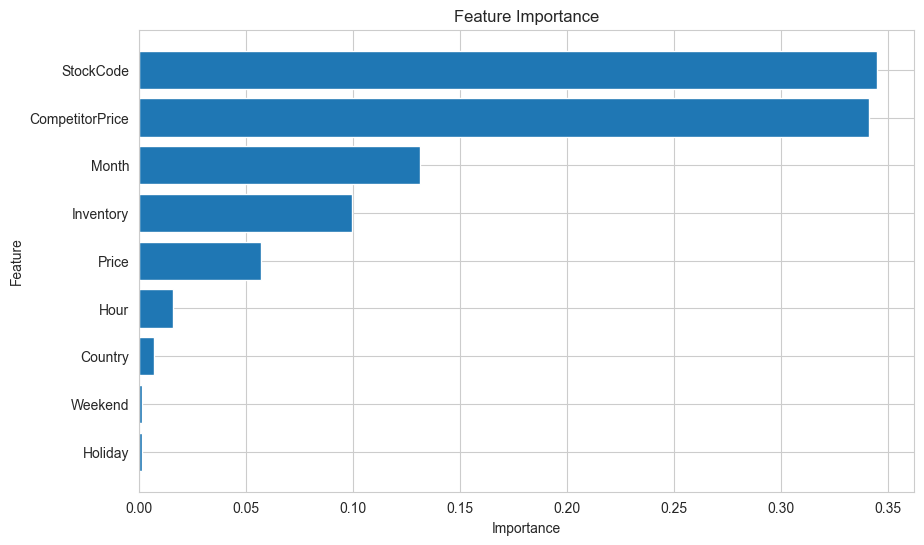

In [66]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

#Visualization

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

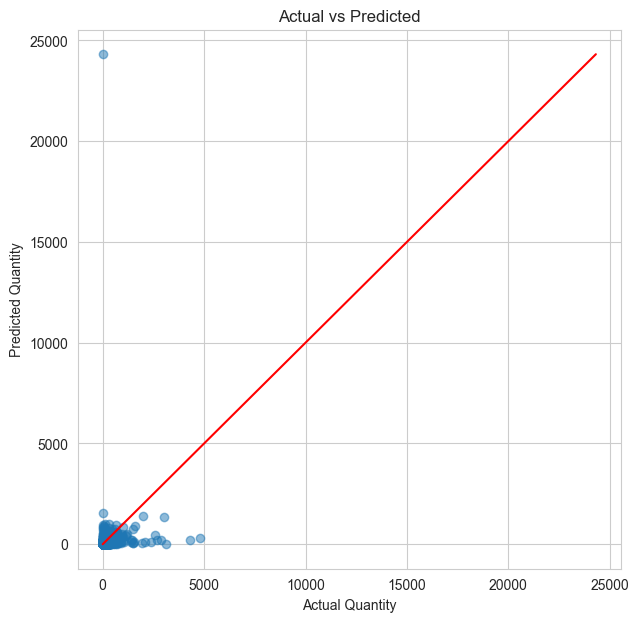

In [67]:
#Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

#Scatter Plot

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red"
)

plt.show()

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [69]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        n_estimators=200
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        n_estimators=200
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0
    )
}

In [70]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append(
        [name, mae, rmse, r2]
    )


Training Linear Regression...

Training Random Forest...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1009
[LightGBM] [Info] Number of data points in the train set: 314154, number of used features: 9
[LightGBM] [Info] Start training from score 13.171448

Training CatBoost...


In [71]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,12.884714,50.468219,0.005224
3,LightGBM,11.067034,68.192985,-0.816222
2,XGBoost,9.928126,75.219393,-1.209780
1,Random Forest,8.523828,96.872122,-2.665110
4,CatBoost,9.751762,119.089785,-4.539090


In [72]:
best_model = results_df.iloc[0]

print("Best Model")
print(best_model)

Best Model
Model       Linear Regression
MAE                 12.884714
RMSE                50.468219
R2 Score             0.005224
Name: 0, dtype: object


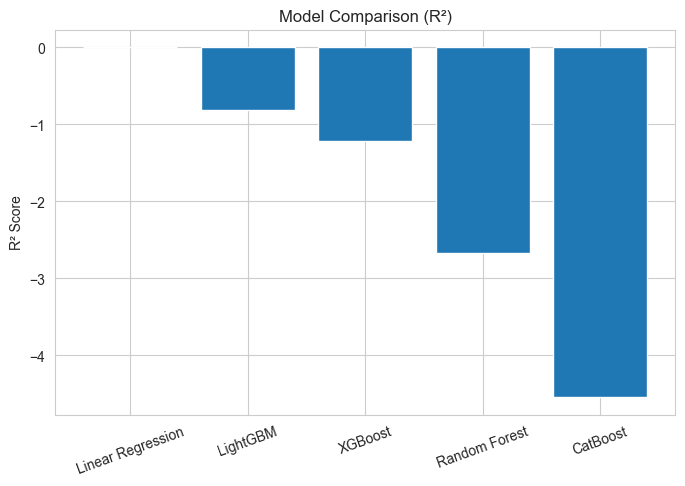

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

plt.show()

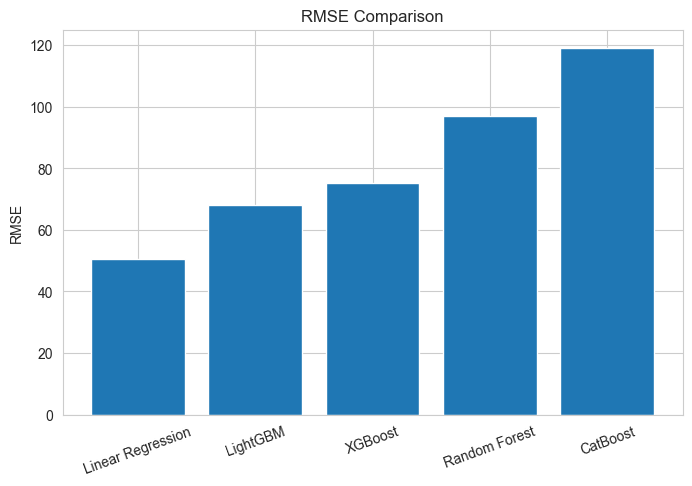

In [74]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.show()

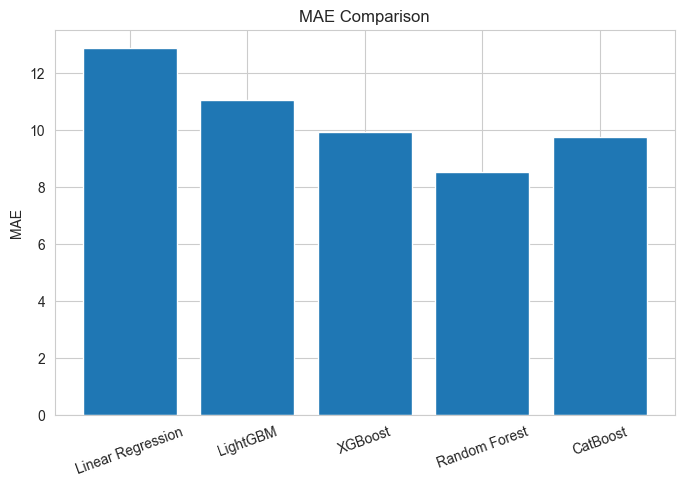

In [75]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xticks(rotation=20)

plt.show()

Define the Dynamic Pricing Function

In [76]:


def dynamic_pricing(
    current_price,
    cost_price,
    competitor_price,
    inventory,
    month,
    hour,
    holiday,
    weekend,
    stock_code,
    country,
    model,
    le_product,
    le_country
):
    # Candidate prices (±20% around current price)
    candidate_prices = np.arange(
        current_price * 0.80,
        current_price * 1.21,
        current_price * 0.05
    )

    results = []

    for price in candidate_prices:

        sample = pd.DataFrame({
            "Price": [price],
            "CompetitorPrice": [competitor_price],
            "Inventory": [inventory],
            "Month": [month],
            "Hour": [hour],
            "Holiday": [holiday],
            "Weekend": [weekend],
            "StockCode": [
                le_product.transform([stock_code])[0]
            ],
            "Country": [
                le_country.transform([country])[0]
            ]
        })

        predicted_quantity = model.predict(sample)[0]

        # Quantity cannot be negative
        predicted_quantity = max(0, predicted_quantity)

        revenue = price * predicted_quantity

        profit = (
            (price - cost_price)
            * predicted_quantity
        )

        results.append([
            round(price, 2),
            round(predicted_quantity, 2),
            round(revenue, 2),
            round(profit, 2)
        ])

    results = pd.DataFrame(
        results,
        columns=[
            "CandidatePrice",
            "PredictedQuantity",
            "Revenue",
            "Profit"
        ]
    )

    best = results.loc[
        results["Profit"].idxmax()
    ]

    return results, best

example

In [77]:
results, best = dynamic_pricing(
    current_price=100,
    cost_price=60,
    competitor_price=98,
    inventory=150,
    month=12,
    hour=18,
    holiday=1,
    weekend=1,
    stock_code="85123A",
    country="United Kingdom",
    model=model,
    le_product=le_product,
    le_country=le_country
)

In [78]:
print(results)

   CandidatePrice  PredictedQuantity  Revenue  Profit
0            80.0               2.25   179.68   44.92
1            85.0               2.25   190.91   56.15
2            90.0               2.25   202.14   67.38
3            95.0               2.25   213.37   78.61
4           100.0               2.25   224.60   89.84
5           105.0               2.25   235.83  101.07
6           110.0               2.25   247.06  112.30
7           115.0               2.25   258.29  123.53
8           120.0               2.25   269.52  134.76


In [79]:
print("Best Price")

print(best)

Best Price
CandidatePrice       120.00
PredictedQuantity      2.25
Revenue              269.52
Profit               134.76
Name: 8, dtype: float64


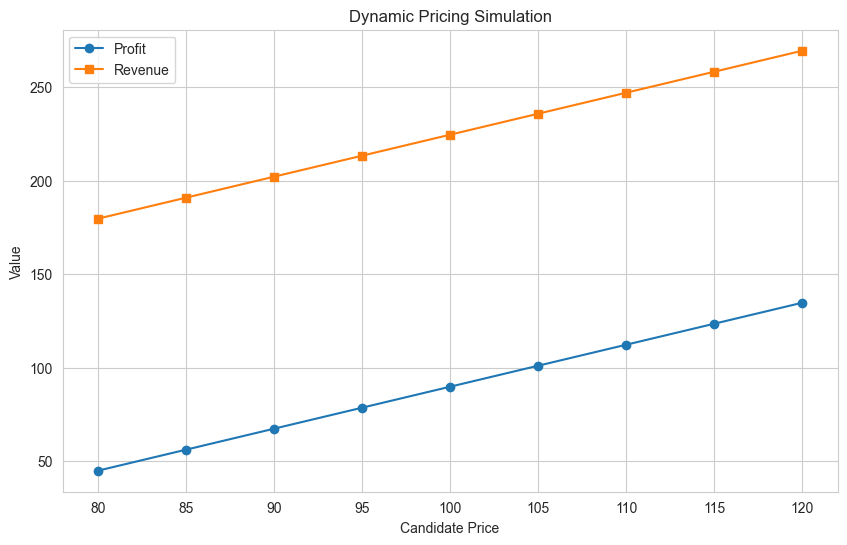

In [80]:


plt.figure(figsize=(10,6))

plt.plot(
    results["CandidatePrice"],
    results["Profit"],
    marker="o",
    label="Profit"
)

plt.plot(
    results["CandidatePrice"],
    results["Revenue"],
    marker="s",
    label="Revenue"
)

plt.xlabel("Candidate Price")
plt.ylabel("Value")
plt.title("Dynamic Pricing Simulation")

plt.legend()

plt.grid(True)

plt.show()

In [81]:
recommended_price = best["CandidatePrice"]

print(
    f"Recommended Price: ${recommended_price:.2f}"
)

Recommended Price: $120.00


In [83]:
import joblib

# Save the trained model
joblib.dump(model, "model.pkl")

# Save the encoders
joblib.dump(le_product, "le_product.pkl")
joblib.dump(le_country, "le_country.pkl")

print("All files saved successfully!")

All files saved successfully!
